# IMDB Movie Rating Prediction Using Machine Learning

## Project Overview

Movie ratings are important indicators of audience reception and movie quality. Predicting ratings can help understand the factors that influence a movie's success.

The objective of this project is to build a machine learning regression model capable of predicting IMDB movie ratings using movie-related information such as genre, director, actors, duration, and votes.

## Goals

- Explore and understand movie data
- Perform data cleaning and preprocessing
- Engineer useful features
- Train regression models
- Evaluate prediction performance

## Dataset Features

The dataset contains:

- Movie Name
- Year
- Duration
- Genre
- Director
- Actors
- Votes
- Rating (Target Variable)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Dataset Exploration

Before building a machine learning model, it is important to understand the structure of the dataset.

This section examines:

- Dataset size
- Available features
- Missing values
- Sample observations

These checks help identify potential preprocessing requirements.

In [39]:
df=pd.read_csv("IMDb Movies India.csv",encoding="latin1")
df.tail()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN
15508,Zulm-O-Sitam,(1998),130 min,"Action, Drama",6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [40]:
df.shape

(15509, 10)

# Missing Value Analysis

Real-world datasets often contain incomplete information.

Missing values can negatively affect model performance and must be handled appropriately before training machine learning models.

This analysis identifies columns requiring treatment.

In [4]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

# Data Cleaning and Preprocessing

Raw datasets typically contain inconsistencies, missing values, and incorrect data formats.

The following preprocessing steps are performed:

- Remove rows with missing target values
- Convert data types
- Handle missing numerical values
- Remove duplicate records
- Prepare data for machine learning

In [5]:
# we should drop based on "Rating " column as it is target and other =s we will impute
df=df.dropna(subset="Rating")

In [6]:
df.shape


(7919, 10)

In [7]:
df.isna().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [8]:
from sklearn.impute import SimpleImputer
mean=SimpleImputer(strategy="mean")


# Feature Formatting

Several features are stored as text and must be converted into numerical format before model training.

Examples:

- Year → Numeric Year
- Duration → Minutes
- Votes → Numeric Count

Machine learning algorithms require numerical inputs for effective learning.

In [9]:
# have to convert value obj==>numerrical for columns year, duration,votes


df["Year"]=df["Year"].str.extract(r"(\d{4})").astype(float)

# methode2 df["Year"].str.replace(r"[()]","",regex=True)



# str-coverts pandas series of year into string
# extract extract the pattern using the regular expression module
# r''- tells python to treat "\" as backlash not space
# \d-0-9 digits
# {4} digit in row 
# r'(\d{4}) find and extract any sequence of 4 digits

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   float64
 2   Duration  5851 non-null   object 
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   object 
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(2), object(8)
memory usage: 680.5+ KB


In [11]:
df["Duration"]=df["Duration"].str.replace("min","").astype(float)


In [12]:
df["Votes"]=df["Votes"].str.replace(",","").astype(float)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   float64
 2   Duration  5851 non-null   float64
 3   Genre     7817 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   float64
 6   Director  7914 non-null   object 
 7   Actor 1   7794 non-null   object 
 8   Actor 2   7719 non-null   object 
 9   Actor 3   7627 non-null   object 
dtypes: float64(4), object(6)
memory usage: 680.5+ KB


In [14]:
num=df.select_dtypes(include="float64")
char=df.select_dtypes(include="object")

from sklearn.impute import SimpleImputer
mean=SimpleImputer(strategy="mean")
most_freq=SimpleImputer(strategy="most_frequent")
df[char.columns]=most_freq.fit_transform(char)
df[num.columns]=mean.fit_transform(num)

In [15]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [16]:
df=df.drop_duplicates()
df.shape

(7919, 10)

In [17]:
df["Rating"].nunique()

84

# Statistical Summary

Descriptive statistics provide an overview of feature distributions including:

- Mean
- Standard Deviation
- Minimum Values
- Maximum Values

This helps identify unusual values and understand feature behavior.

In [18]:
df.describe()

,Year,Duration,Rating,Votes
count,7919.000000,7919.00000,7919.000000,7919.000000
mean,1993.321758,132.29448,5.841621,1938.520394
std,20.463770,22.82601,1.381777,11602.415952
min,1917.000000,21.00000,1.100000,5.000000
25%,1979.500000,124.00000,4.900000,16.000000
50%,1997.000000,132.29448,6.000000,55.000000
75%,2011.000000,143.00000,6.800000,404.000000
max,2021.000000,321.00000,10.000000,591417.000000


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns, relationships, and trends within the dataset.

The objective is to understand:

- Movie production trends
- Popular genres
- Influential directors
- Frequently appearing actors
- Feature relationships

These insights guide feature engineering and model development.

# Correlation Analysis

Correlation measures the strength and direction of relationships between numerical variables.

The heatmap provides a visual representation of pairwise correlations and helps identify variables that may influence movie ratings.

<Axes: >

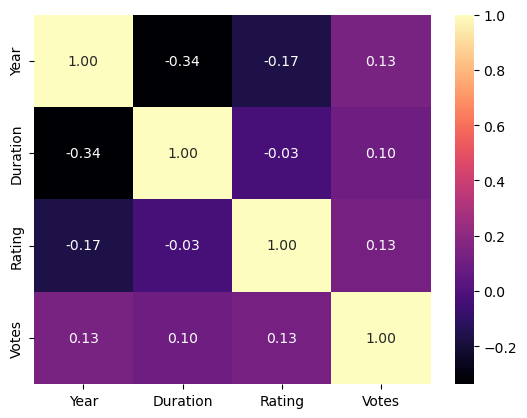

In [19]:
corr_mat=num.corr()
sns.heatmap(corr_mat,cmap="magma",annot=True,fmt=".2f")

### Interpretation

The heatmap shows the relationships among numerical features.

Features exhibiting stronger correlation with ratings may provide useful information for prediction.

Weak correlations indicate that multiple features may need to be combined to achieve accurate predictions.

# Distribution of Numerical Features

Histograms are used to examine the distribution of numerical variables.

This analysis helps identify:

- Skewness
- Data concentration
- Outliers
- Feature ranges

Understanding these distributions is important before model training.

array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Duration'}>],
       [<Axes: title={'center': 'Rating'}>,
        <Axes: title={'center': 'Votes'}>]], dtype=object)

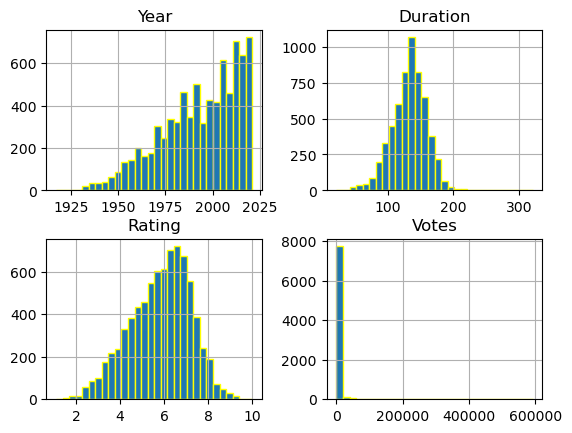

In [20]:
num.hist(bins=30,edgecolor="Yellow")

In [21]:
# 1)top 10 directors with most involvment in movies
# 2)top 10 genre
# 3)top 10 actors with most movie involvment
# 4)average ratings of movies per year

# Top 10 Directors by Movie Count

This visualization identifies directors with the highest number of movies in the dataset.

Purpose:

- Understand industry representation
- Identify highly active directors
- Explore potential influence of directors on ratings

C:\Users\akhil\AppData\Local\Temp\ipykernel_12856\2290717315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_10_directors.index,x=top_10_directors.values,palette="magma")


Text(0.5, 1.0, 'Top 10 directors with most movies')

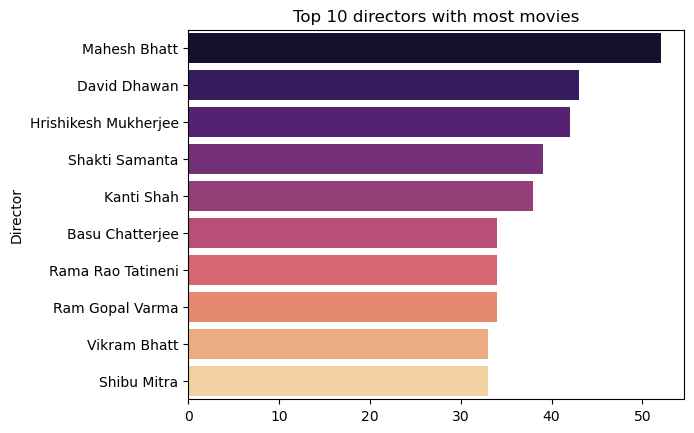

In [22]:
# 1)top 10 directors with most involvment in movies
top_10_directors=df["Director"].value_counts(ascending=False).head(10)
sns.barplot(y=top_10_directors.index,x=top_10_directors.values,palette="magma")
plt.title("Top 10 directors with most movies")

### Interpretation

A small number of directors contribute a large number of movies.

This suggests that director-related information may be useful for predicting movie ratings.

# Top 10 Genres

Genres influence audience expectations and movie ratings.

This visualization identifies the most common genres present in the dataset.

C:\Users\akhil\AppData\Local\Temp\ipykernel_12856\612040476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genre.values,y=top_10_genre.index,palette="cividis")


<Axes: ylabel='Genre'>

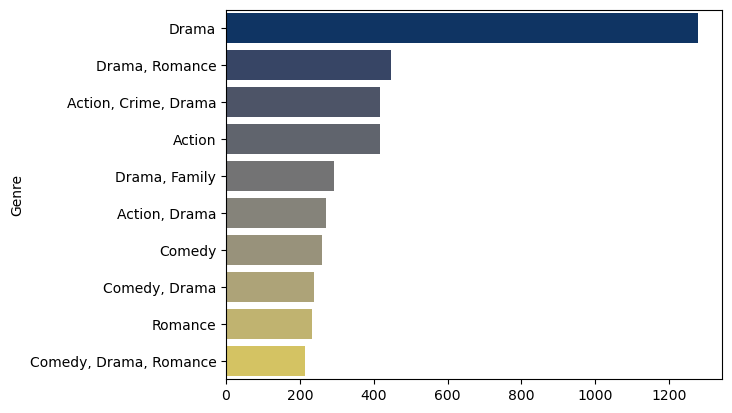

In [23]:
top_10_genre=df["Genre"].value_counts(ascending=False).head(10)
sns.barplot(x=top_10_genre.values,y=top_10_genre.index,palette="cividis")

### Interpretation

Certain genres dominate the dataset, indicating audience and industry preferences.

Genre information may contribute significantly to rating prediction.

# Top 10 Actors by Appearance Count

Actors often influence audience engagement and movie popularity.

This analysis identifies the actors appearing most frequently in the dataset.

Pran                  377
Rekha                 333
Jeetendra             304
Mithun Chakraborty    231
Dharmendra            217
Ashok Kumar           176
Amitabh Bachchan      163
Rajesh Khanna         132
Shashi Kapoor         126
Sanjay Dutt           123
Name: count, dtype: int64


C:\Users\akhil\AppData\Local\Temp\ipykernel_12856\1597656229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_actors.values,y=top_10_actors.index,palette="coolwarm")


Text(0, 0.5, 'actors')

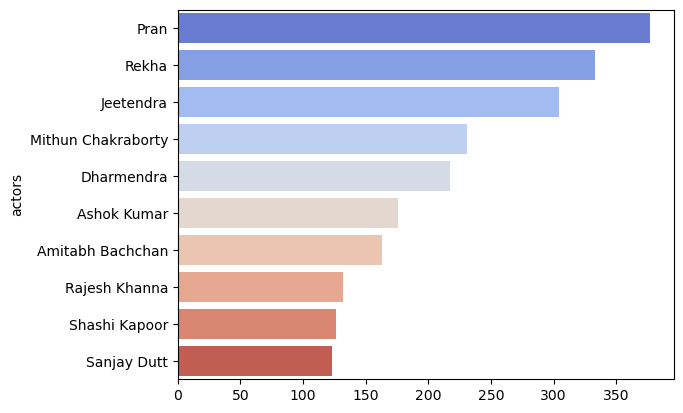

In [24]:
actors=pd.concat([df["Actor 1"],df["Actor 2"],df["Actor 3"]])
top_10_actors=actors.value_counts().head(10)
print(top_10_actors) 
sns.barplot(x=top_10_actors.values,y=top_10_actors.index,palette="coolwarm")
plt.ylabel("actors")


### Interpretation

Several actors appear repeatedly across movies.

This suggests actor-related information may contain predictive value for rating estimation.

# Movie Production Trends Over Time

This visualization examines:

- Number of movies released each year
- Average movie ratings over time

The goal is to identify long-term trends in movie production and audience ratings.

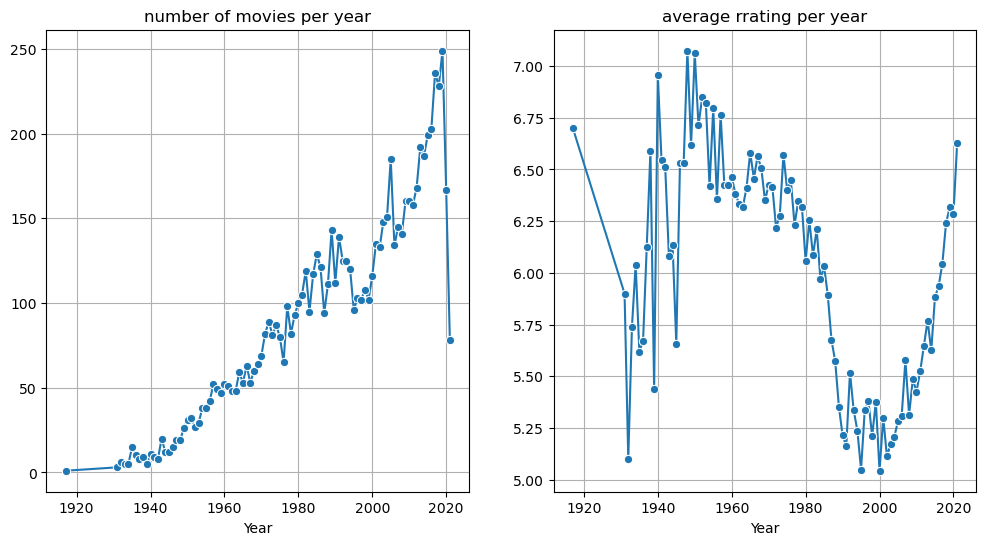

In [25]:
# number of movies per year and average of rating of movies per year
fig,ax=plt.subplots(1,2,figsize=(12,6))
movies_per_year=df["Year"].value_counts()

ax[0].set_title("number of movies per year")
sns.lineplot(x=movies_per_year.index,y=movies_per_year.values,ax=ax[0],marker="o")
ax[0].grid(True)

# average rrating per year
avg_rat_year=df.groupby("Year")["Rating"].mean()
# print(avg_rat_year)


ax[1].set_title("average rrating per year")
sns.lineplot(x=avg_rat_year.index,y=avg_rat_year.values,marker="o",ax=ax[1])

plt.grid(True)

### Interpretation

The analysis highlights how movie production volume and average ratings change over time.

Temporal trends may provide useful information for prediction models.

# Feature Engineering

Feature engineering is one of the most important stages of machine learning.

New features are created using historical rating information from:

- Directors
- Genres
- Actors

To avoid target leakage, all statistics are calculated exclusively on the training dataset and then applied to the test dataset.

This ensures realistic model evaluation.

In [26]:
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019.0,109.00000,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019.0,110.00000,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997.0,147.00000,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005.0,142.00000,"Drama, Romance, War",7.4,1086.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012.0,82.00000,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15501,Zulm Ki Hukumat,1992.0,132.29448,"Action, Crime, Drama",5.3,135.0,Bharat Rangachary,Dharmendra,Moushumi Chatterjee,Govinda
15503,Zulm Ki Zanjeer,1989.0,125.00000,"Action, Crime, Drama",5.8,44.0,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15504,Zulm Ko Jala Doonga,1988.0,132.29448,Action,4.6,11.0,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,1999.0,129.00000,"Action, Drama",4.5,655.0,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [27]:
from sklearn.model_selection import train_test_split
# X=df.drop(columns=["Name","Genre","Director","Actor 1","Actor 2","Actor 3","Rating"])
# y=df["Rating"]
train_df,test_df=train_test_split(df,random_state=42,test_size=.2)

In [28]:
dir_mean=train_df.groupby("Director")["Rating"].mean()
# now mapping to traun and test set
train_df["avg_dir_rating"]=train_df["Director"].map(dir_mean)
test_df["avg_dir_rating"]=test_df["Director"].map(dir_mean)


In [29]:
# similarly for actor 1 2 3 and genre
gen_mean=train_df.groupby("Genre")["Rating"].mean()
train_df["avg_genre_rating"]=train_df["Genre"].map(gen_mean)
test_df["avg_genre_rating"]=test_df["Genre"].map(gen_mean)

mean_a1=train_df.groupby("Actor 1")["Rating"].mean()
train_df["avg_act1_rating"]=train_df["Actor 1"].map(mean_a1)
test_df["avg_act1_rating"]=test_df["Actor 1"].map(mean_a1)

mean_a2=train_df.groupby("Actor 2")["Rating"].mean()
train_df["avg_act2_rating"]=train_df["Actor 2"].map(mean_a2)
test_df["avg_act2_rating"]=test_df["Actor 2"].map(mean_a2)

mean_a3=train_df.groupby("Actor 3")["Rating"].mean()
train_df["avg_act3_rating"]=train_df["Actor 3"].map(mean_a3)
test_df["avg_act3_rating"]=test_df["Actor 3"].map(mean_a3)


In [30]:
# avg_genre_rating=df.groupby("Genre")["Rating"].transform("mean")
# df["avg_genre_rating"]=avg_genre_rating
# #.mean gives pd series of mean of each group
# # but .transfrom("mean") gives pd series of mean of each grp seperatley giving same no. of rows as that of df                                        

# avg_dir_rating=df.groupby("Director")["Rating"].transform("mean")
# df["avg_dir_rating"]=avg_dir_rating
# avg_actor1_rating=df.groupby("Actor 1")["Rating"].transform("mean")
# df["avg_actor1_rating"]=avg_actor1_rating
# avg_actor2_rating=df.groupby("Actor 2")["Rating"].transform("mean")
# df["avg_actor2_rating"]=avg_actor2_rating
# avg_actor3_rating=df.groupby("Actor 3")["Rating"].transform("mean")
# df["avg_actor3_rating"]=avg_actor3_rating


In [31]:
test_df.isnull().sum()

Name                  0
Year                  0
Duration              0
Genre                 0
Rating                0
Votes                 0
Director              0
Actor 1               0
Actor 2               0
Actor 3               0
avg_dir_rating      449
avg_genre_rating     57
avg_act1_rating     379
avg_act2_rating     434
avg_act3_rating     463
dtype: int64

In [32]:
# now i will fill the values with global mean 
global_mean=train_df["Rating"].mean()
cols=["avg_dir_rating","avg_genre_rating","avg_act1_rating","avg_act2_rating","avg_act3_rating"]
for col in cols:
    train_df[col]=train_df[col].fillna(global_mean)
    test_df[col]=test_df[col].fillna(global_mean)

In [33]:
test_df.isnull().sum()

Name                0
Year                0
Duration            0
Genre               0
Rating              0
Votes               0
Director            0
Actor 1             0
Actor 2             0
Actor 3             0
avg_dir_rating      0
avg_genre_rating    0
avg_act1_rating     0
avg_act2_rating     0
avg_act3_rating     0
dtype: int64

In [35]:
x_train=train_df.drop(columns=["Name","Genre","Rating","Director","Actor 1","Actor 2","Actor 3"])
y_train=train_df["Rating"]
x_test=test_df.drop(columns=["Name","Genre","Rating","Director","Actor 1","Actor 2","Actor 3"])
y_test=test_df["Rating"]

In [36]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(x_train,y_train)
yp1=LR.predict(x_test)
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
# print("MSE train",mean_squared_error(x_train,y_train))
print("MSE test",mean_squared_error(y_test,yp1))
print("mean_absolute_error test",mean_absolute_error(y_test,yp1))
print("r2_score test",r2_score(y_test,yp1))


MSE test 1.3714512092101427
mean_absolute_error test 0.9128081958880692
r2_score test 0.2623216018862532


In [37]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=101,random_state=42)
rf.fit(x_train,y_train)


yp2=rf.predict(x_test)
print("MSE test",mean_squared_error(y_test,yp2))
print("mean_absolute_error test",mean_absolute_error(y_test,yp2))
print("r2_score test",r2_score(y_test,yp2))

MSE test 1.4312039458896386
mean_absolute_error test 0.9140939093909393
r2_score test 0.23018170308370733
